#### Veri yapıyoz

In [5]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.10.11
Platform:Windows-10-10.0.26200-SP0
seaborn: 0.13.2
pandas: 2.3.3
numpy: 2.2.6
sklearn: 1.7.2


In [6]:
from sklearn.datasets import load_diabetes, load_breast_cancer

diab=load_diabetes(as_frame=True)
diab.frame.head(2)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0


In [7]:
diab.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


##### Veride x (bağımsız) ve y(bağımlı)'leri işaretliyoruz

In [8]:
X_reg =diab.data
y_reg=diab.target

In [9]:
X_reg= diab.frame.drop("target",axis=1)
y_reg=diab.frame["target"]

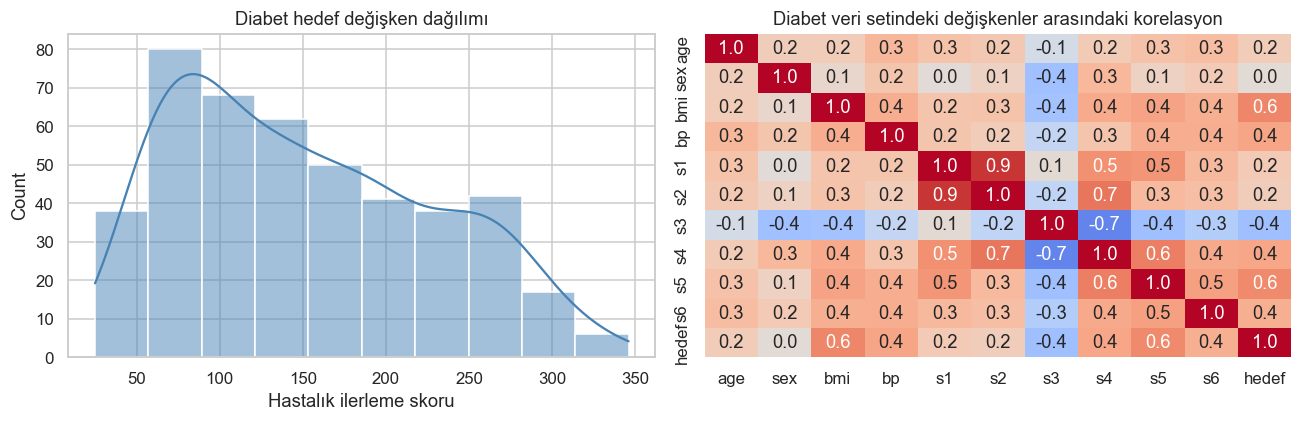

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(y_reg,kde=True,ax=axes[0],color="steelblue")
axes[0].set_title("Diabet hedef değişken dağılımı")
axes[0].set_xlabel("Hastalık ilerleme skoru")

corr =pd.concat([X_reg,y_reg.rename("hedef")],axis = 1).corr()
sns.heatmap(corr, annot = True, fmt=".1f",cmap="coolwarm",center=0,axes=axes[1],cbar=False)
axes[1].set_title("Diabet veri setindeki değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

#### Train - test'imizi nasıl böldük (20'ye 80 default)

In [11]:
from sklearn.model_selection import train_test_split
Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_reg,y_reg,test_size=0.2,random_state=SEED)

In [12]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

353


89

#### regresyon kodlamaya geçiyoruz

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train,yr_train)

linear = LinearRegression().fit(Xr_train,yr_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,Xr_train,yr_train,"Baseline"),
    regresyon_raporu(linear,Xr_test,yr_test,"Linear")
]).set_index("Model").round(3)
sonuc


,Mae,mse,rmse,r2
Model,,,,
Baseline,66.448,6076.398,77.951,0.000
Linear,42.794,2900.194,53.853,0.453


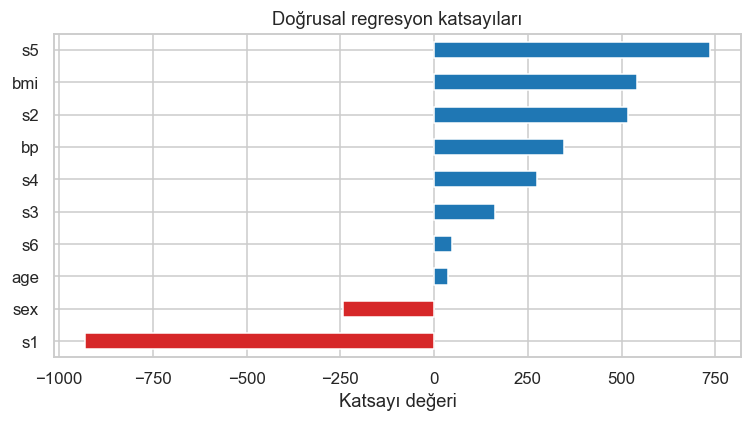

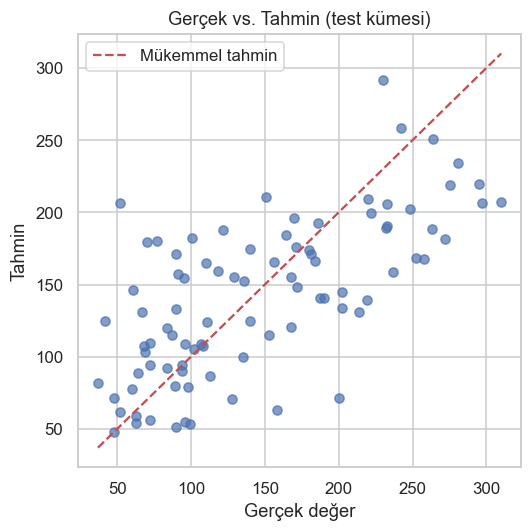

In [14]:
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()


tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.7)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

#### Diğer regresyon modelleri

In [18]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [19]:
modeller= {
    "Doğrusal": make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(),Lasso(alpha=1.0))
}

satirlar =[]

for ad,m in modeller.items():
  m.fit(Xr_train,yr_train)
  satirlar.append(regresyon_raporu(m,Xr_test,yr_test,ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,42.794,2900.194,53.853,0.453
Ridge,42.812,2892.015,53.777,0.454
Lasso,42.803,2824.568,53.147,0.467


In [22]:
ridge= modeller["Ridge"].named_steps["ridge"]
pd.Series(ridge.coef_,index=X_reg.columns).round(2).to_frame("Ridge değişkenler").T

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
Ridge değişkenler,1.81,-11.45,25.73,16.73,-34.67,17.05,3.37,11.76,31.38,2.46


In [23]:
lasso= modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_,index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
Lasso değişkenler,0.69,-9.3,26.22,15.66,-8.23,-0.0,-9.02,3.42,22.64,2.1


In [24]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])
